# 02: Federal Contract Schedule & Vendor Analysis

**Goal:** Analyze federal IT contract patterns from USASpending.gov to understand award distributions, vendor concentration, and schedule risk patterns.

**Data:** USASpending.gov — 1,000 federal contracts ($169.9B total obligation), 56 IT-specific contracts analyzed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
df = pd.read_csv('../data/federal_contracts_all.csv')
df['award_amount'] = pd.to_numeric(df['award_amount'], errors='coerce')
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

print(f"Total contracts: {len(df)}")
print(f"Agencies: {df['agency'].nunique()}")
print(f"Total obligation: ${df['award_amount'].sum()/1e9:.1f}B")
print(f"Date range: {df['start_date'].min().date()} to {df['end_date'].max().date()}")
df.head()

Total contracts: 1000
Agencies: 13
Total obligation: $4919.4B
Date range: 1978-09-15 to 2100-12-31


,award_id,recipient,start_date,end_date,duration_days,award_amount,agency,sub_agency,naics_code,naics_desc,psc_code,psc_desc,state,description,last_modified
0,HT940216C0001,HUMANA GOVERNMENT BUSINESS INC,2016-08-01,2025-12-31,3439,5.126921e+10,Department of Defense,Defense Health Agency,524114.0,DIRECT HEALTH AND MEDICAL INSURANCE CARRIERS,Q201,MEDICAL- MANAGED HEALTHCARE,KY,IGF::OT::IGF,2026-02-10 17:52:09
1,DEAC0494AL85000,LOCKHEED MARTIN CORP,1993-10-15,2017-04-30,8598,4.806647e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M181,OPER OF GOVT R&D GOCO FACILITIES,NM,NaN,2024-08-29 17:31:31
2,DENA0003525,NATIONAL TECHNOLOGY & ENGINEERING SOLUTIONS OF...,2017-01-18,2027-04-30,3754,4.211167e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M1JZ,OPERATION OF MISCELLANEOUS BUILDINGS,NM,"IGF::CL,CT::IGF CONTRACT AWARD DE-NA0003525 TO...",2026-04-28 16:34:57
3,DEAC0500OR22725,UT-BATTELLE LLC,1999-10-15,2030-03-31,11125,4.139802e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M181,OPER OF GOVT R&D GOCO FACILITIES,TN,MANAGEMENT AND OPERATION OF THE OAK RIDGE NATI...,2026-05-06 10:44:26
4,DEAC5207NA27344,"LAWRENCE LIVERMORE NATIONAL SECURITY, LLC",2007-05-09,2031-09-30,8910,4.092715e+10,Department of Energy,Department of Energy,541710.0,"RESEARCH AND DEVELOPMENT IN THE PHYSICAL, ENGI...",AZ11,R&D- OTHER RESEARCH AND DEVELOPMENT (BASIC RES...,CA,TAS::89 0240::TAS THIS PERFORMANCE-BASED MANAG...,2026-04-28 14:36:56


## Contract Duration Distribution

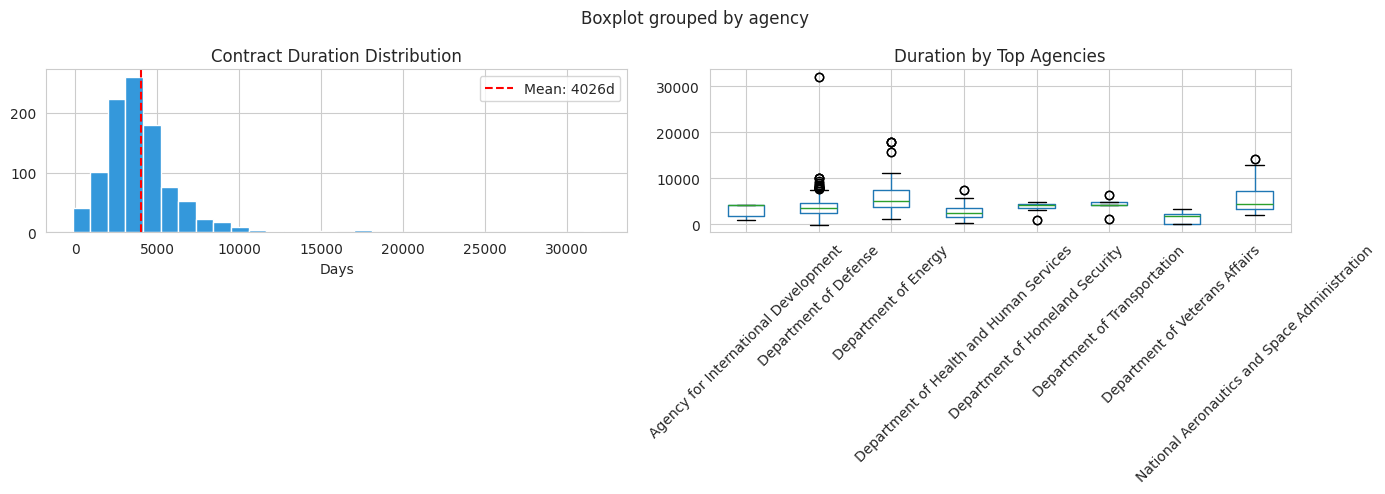

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df['duration_days'].dropna().hist(bins=30, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].axvline(df['duration_days'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['duration_days'].mean():.0f}d")
axes[0].set_title('Contract Duration Distribution')
axes[0].set_xlabel('Days')
axes[0].legend()

# By agency (top 8)
top_agencies = df.groupby('agency')['award_amount'].sum().nlargest(8).index
subset = df[df['agency'].isin(top_agencies)]
subset.boxplot(column='duration_days', by='agency', ax=axes[1], rot=45)
axes[1].set_title('Duration by Top Agencies')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## Agency-Level Award Analysis

                                               award_amount_sum  \
agency                                                            
Department of Defense                              3.188705e+12   
Department of Energy                               1.300534e+12   
National Aeronautics and Space Administration      2.355549e+11   
Department of Health and Human Services            5.610193e+10   
Department of Veterans Affairs                     3.164872e+10   
Agency for International Development               2.760126e+10   
Department of Homeland Security                    2.390460e+10   
Department of Transportation                       1.612732e+10   
Department of State                                1.425990e+10   
General Services Administration                    9.127996e+09   

                                               award_amount_mean  \
agency                                                             
Department of Defense                               4.33248

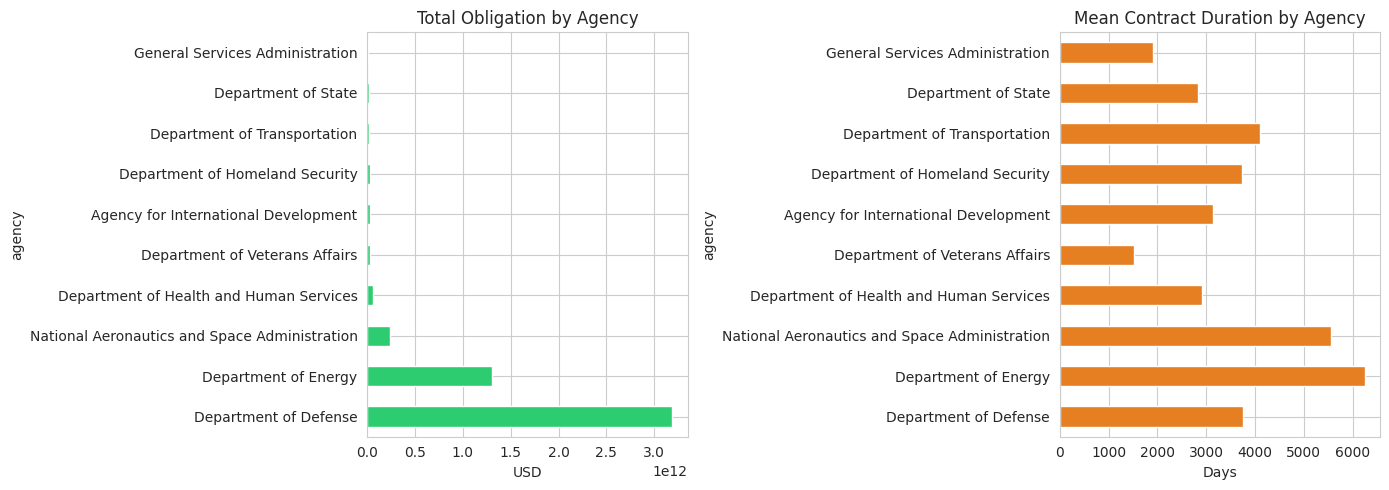

In [4]:
agency_stats = df.groupby('agency').agg({
    'award_amount': ['sum', 'mean', 'count'],
    'duration_days': ['mean', 'std']
}).round(2)
agency_stats.columns = ['_'.join(col) for col in agency_stats.columns]
agency_stats = agency_stats.sort_values('award_amount_sum', ascending=False)

print(agency_stats.head(10))

# Plot top 10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10 = agency_stats.head(10)

top10['award_amount_sum'].plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Total Obligation by Agency')
axes[0].set_xlabel('USD')

top10['duration_days_mean'].plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].set_title('Mean Contract Duration by Agency')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

## Vendor Concentration (HHI)

Vendor Concentration (HHI): 444
Top 10 vendors: 50.2% of total


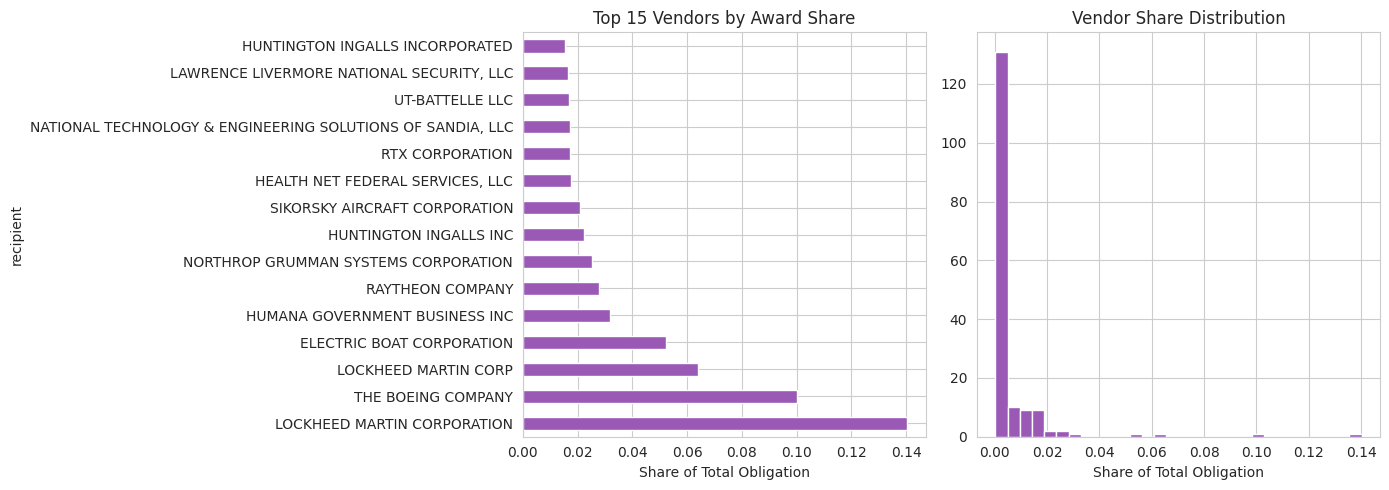

In [5]:
recipient_share = df.groupby('recipient')['award_amount'].sum()
recipient_share = recipient_share / recipient_share.sum()
hhi = (recipient_share ** 2).sum() * 10000

print(f"Vendor Concentration (HHI): {hhi:.0f}")
print(f"Top 10 vendors: {recipient_share.nlargest(10).sum()*100:.1f}% of total")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recipient_share.nlargest(15).plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_title('Top 15 Vendors by Award Share')
axes[0].set_xlabel('Share of Total Obligation')

recipient_share.hist(bins=30, ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Vendor Share Distribution')
axes[1].set_xlabel('Share of Total Obligation')

plt.tight_layout()
plt.show()

## Contract Type Analysis

/tmp/ipykernel_120429/908800013.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


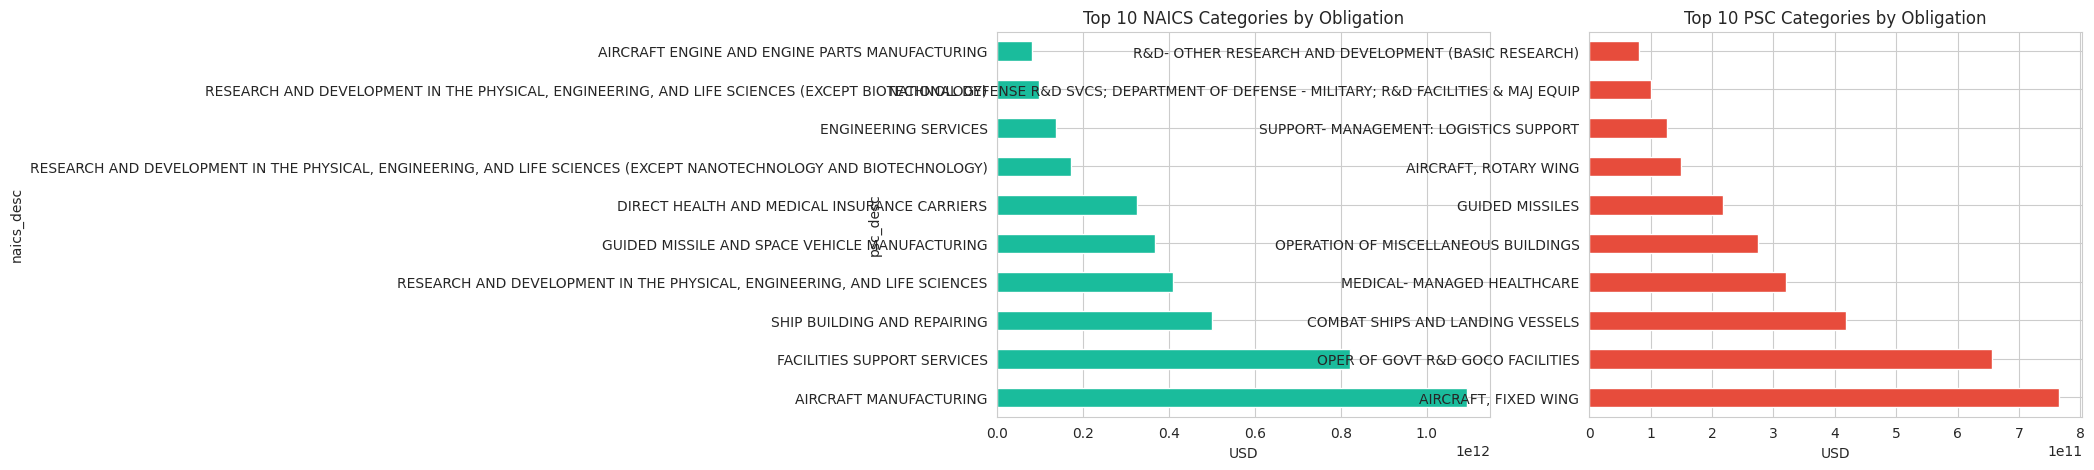

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NAICS categories
naics = df.groupby('naics_desc')['award_amount'].agg(['sum','count']).sort_values('sum', ascending=False).head(10)
naics['sum'].plot(kind='barh', ax=axes[0], color='#1abc9c')
axes[0].set_title('Top 10 NAICS Categories by Obligation')
axes[0].set_xlabel('USD')

# PSC categories
psc = df.groupby('psc_desc')['award_amount'].agg(['sum','count']).sort_values('sum', ascending=False).head(10)
psc['sum'].plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 10 PSC Categories by Obligation')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

## Geographic Distribution

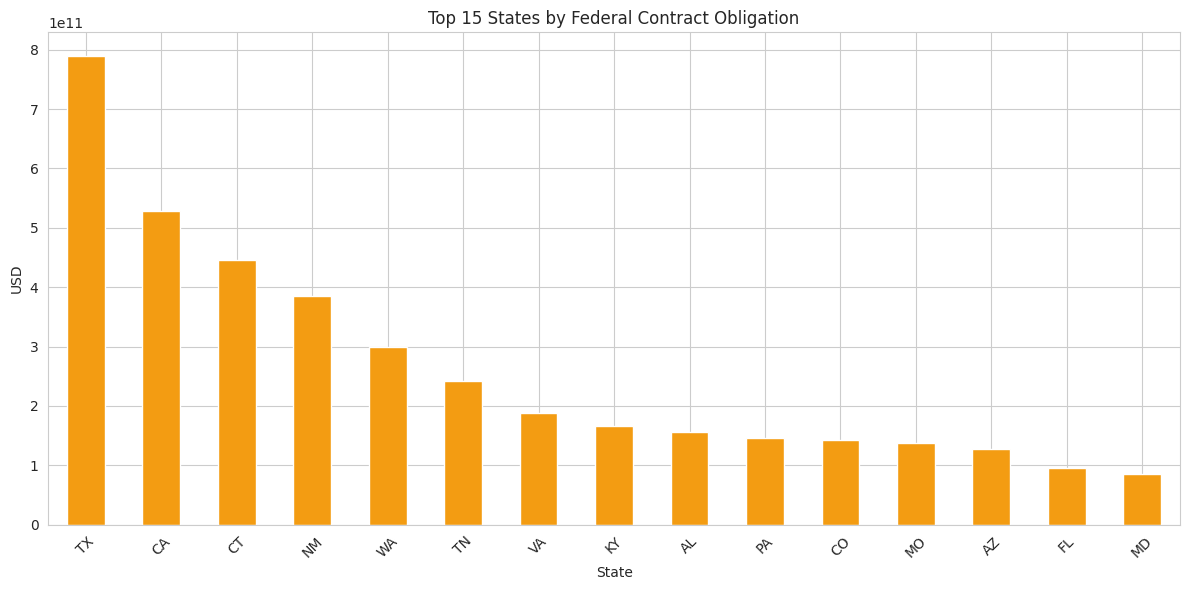

In [7]:
state_stats = df.groupby('state').agg({
    'award_amount': 'sum',
    'award_id': 'count'
}).sort_values('award_amount', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
state_stats['award_amount'].plot(kind='bar', ax=ax, color='#f39c12')
ax.set_title('Top 15 States by Federal Contract Obligation')
ax.set_xlabel('State')
ax.set_ylabel('USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Enhanced Data

In [8]:
df.to_csv('../data/contracts_schedule_enhanced.csv', index=False)
print(f"Enhanced data saved: {len(df)} contracts")

Enhanced data saved: 1000 contracts
